# TweetAge – Clasificación del rango de edad a partir de tweets
**Curso de Procesamiento del Lenguaje Natural · Maestría en Inteligencia Artificial · Pontificia Universidad Javeriana**

Equipo: ____________________

## Objetivo
Predecir el rango de edad del autor de un tweet en español a partir **únicamente del texto**. La submission usa tres etiquetas (`18-24`, `35-49`, `65-xx`) y la métrica es **F1 macro**. Por reglas del curso no se usan modelos preentrenados ni la librería *transformers*.

## Decisiones de diseño (resumen del informe de estado del arte)
| Decisión | Justificación |
|---|---|
| TF-IDF de palabras (1-2) y de caracteres (2-5) con SVM lineal | Estrategia ganadora en PAN sin preentrenamiento (Basile et al., 2018; Moreno-Sandoval et al., 2021) |
| Preprocesamiento mínimo: **no** quitar stopwords, menciones, mayúsculas ni alargamientos | En edad, el "ruido" es señal (Eisenstein, 2013); el preprocesamiento "en bruto" fue el mejor en Moreno-Sandoval et al. (2022) |
| Conservar los @usuarios como tokens | En nuestro descriptivo, reemplazarlos bajó el F1 macro de 0,554 a 0,444 |
| Variables de estilo en 5 dimensiones: léxica, sintáctica, simbólica, participación, complementaria | Moreno-Sandoval et al. (2021); Rao et al. (2010) |
| Índices de legibilidad (Szigriszt-Pazos, Fernández Huerta) | ε² = 0,075 y 0,029 en el descriptivo; Szigriszt Pazos (1993), Fernández Huerta (1959) |
| Validación estratificada y F1 macro | Métrica oficial; evita sobreestimar clases fáciles (Sokolova & Lapalme, 2009) |

## Estructura del notebook
1. Configuración y lectura de datos
2. Etiquetas de tres grupos y limpieza
3. Ingeniería de variables (estilo y legibilidad) con verificación descriptiva
4. Representación TF-IDF
5. Experimentos de ablación y selección de modelo
6. Ensamble por votación suave
7. Evaluación e interpretación
8. Modelo final y archivo de submission

## 1. Configuración

Todos los parámetros que se pueden cambiar están en esta celda:
- `MODE`: cómo llevar los 6 rangos del train a las 3 etiquetas de la submission. `'agrupar'` une rangos contiguos; `'filtrar'` entrena solo con las 3 clases exactas. **Confirmar con el profesor cuál corresponde al test.**
- `SAMPLE_FRAC`: fracción del train para pruebas rápidas (`None` = todo).
- `RUN_CV`: activa la validación cruzada de 5 particiones del modelo elegido (más lenta).

In [1]:
TRAIN_PATH  = r'C:\Users\leonk\Documents\MINTA 2025-01\PLN\age_train.csv'   # ajustar a la ruta real
TEST_PATH   = r'C:\Users\leonk\Documents\MINTA 2025-01\PLN\age_test.csv'
SAMPLE_PATH = r'C:\Users\leonk\Documents\MINTA 2025-01\PLN\age_sample_submission.csv'
OUT_PATH    = 'age_submission.csv'

MODE        = 'agrupar'      # 'agrupar' o 'filtrar'
SAMPLE_FRAC = None           # p. ej. 0.2 para pruebas rápidas
RUN_CV      = False          # validación cruzada de 5 particiones del modelo elegido
SEED        = 42

In [3]:
import os, re, html, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.stats import kruskal

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_colwidth', 120)
GROUPS = ['18-24', '35-49', '65-xx']

## 2. Lectura de datos

Los archivos **no** son CSV estándar: usan `;` como separador, tienen marca BOM (`utf-8-sig`), algunos tweets contienen saltos de línea entre comillas y los textos vienen rellenados con espacios hasta 140 caracteres. `keep_default_na=False` evita que textos como "NA" o "null" se conviertan en valores faltantes.

In [4]:
def load(path):
    df = pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str, keep_default_na=False)
    df['text'] = df['text'].str.strip()
    return df

train_raw = load(TRAIN_PATH)
test_raw  = load(TEST_PATH)
if SAMPLE_FRAC:
    train_raw = train_raw.groupby('age_range', group_keys=False).sample(frac=SAMPLE_FRAC, random_state=SEED)
print('Train:', train_raw.shape, '| Test:', test_raw.shape)
train_raw.age_range.value_counts().sort_index()

Train: (169336, 3) | Test: (112892, 2)


age_range
13-17    28863
18-24    28676
25-34    28347
35-49    28230
50-64    28060
65-xx    27160
Name: count, dtype: int64

## 3. Etiquetas de tres grupos y limpieza

Con `MODE='agrupar'` cada etiqueta representa un bloque generacional: 13-24 → `18-24`, 25-49 → `35-49`, 50+ → `65-xx`.

**Limpieza mínima** (sección 5.3 del informe):
- `html.unescape` decodifica entidades como `&lt;3` → `<3` (un corazón), `&amp;` → `&`.
- Se excluyen del entrenamiento los tweets vacíos y los que contienen `#¿NOMBRE?` (error `#NAME?` de Excel en español; el texto original se perdió).
- **No** se eliminan stopwords, menciones, hashtags, mayúsculas ni alargamientos, porque son marcas de edad.

In [5]:
MAP_AGRUPAR = {'13-17': '18-24', '18-24': '18-24',
               '25-34': '35-49', '35-49': '35-49',
               '50-64': '65-xx', '65-xx': '65-xx'}

def prep(texts):
    return pd.Series(texts).fillna('').map(html.unescape).str.strip()

def is_junk(texts):
    t = pd.Series(texts)
    return (t == '') | t.str.contains('#¿NOMBRE', regex=False)

train = train_raw.copy()
if MODE == 'agrupar':
    train['y'] = train.age_range.map(MAP_AGRUPAR)
else:
    train = train[train.age_range.isin(GROUPS)].copy()
    train['y'] = train.age_range

train['text'] = prep(train.text).values
junk = is_junk(train.text).values
print(f'Tweets descartados (vacíos o #¿NOMBRE?): {junk.sum()}')
train = train[~junk].reset_index(drop=True)

test = test_raw.copy()
test['text'] = prep(test.text).values

dist = train.y.value_counts().reindex(GROUPS)
pd.DataFrame({'n': dist, '%': (dist / len(train) * 100).round(1)})

Tweets descartados (vacíos o #¿NOMBRE?): 155


,n,%
y,,
18-24,57411,33.9
35-49,56550,33.4
65-xx,55220,32.6


## 4. Ingeniería de variables

### 4.1 Variables de estilo
Se organizan según las cinco dimensiones de Moreno-Sandoval et al. (2021), adaptadas a **un tweet por fila** (las medidas de asimetría y curtosis por perfil no aplican):

| Dimensión | Variables |
|---|---|
| Léxica | longitud, número de palabras, longitud media de palabra, diversidad léxica, truncado a 140 |
| Sintáctica | pronombres 1ª sing., tú, vos, usted, 1ª pl., 3ª sing., 3ª pl.; conectores (SFL) |
| Simbólica | hashtags, emoticones de texto, risas, alargamientos, mayúsculas, signos repetidos |
| Participación | retweet, respuesta, menciones |
| Complementaria | URL, tweet que es solo un enlace |

El corpus no tiene tildes ni emojis (está normalizado a ASCII), por eso no se incluyen variables de tildes omitidas ni conteo de emojis. La variable `p3s` incluye "el/la/lo" porque sin tildes no se distingue "él" de "el"; en la práctica mide uso de artículos y formalidad.

In [22]:
PRON = {
    'p1s':     r'\b(?:yo|me|mi|mis|conmigo)\b',
    'p2s_tu':  r'\b(?:tu|tus|te|ti|contigo)\b',
    'p2s_vos': r'\bvos\b',
    'p2s_ud':  r'\b(?:usted|ud|uds|ustedes)\b',
    'p1p':     r'\b(?:nosotros|nosotras|nos|nuestro|nuestra|nuestros|nuestras)\b',
    'p3s':     r'\b(?:el|ella|le|lo|la|su|sus)\b',
    'p3p':     r'\b(?:ellos|ellas|les|los)\b',
}
CONECTORES = {   # categorías de la lingüística sistémico-funcional (material del curso)
    'con_extension':   r'\b(?:y|e|o|u|pero|ademas|tambien|sino)\b',
    'con_elaboracion': r'\b(?:es decir|por ejemplo|o sea|osea)\b',
    'con_causal':      r'\b(?:porque|pq|xq|ya que|si|entonces|por eso|aunque)\b',
}

def style_features(texts):
    s = pd.Series(texts).reset_index(drop=True)
    low = s.str.lower()
    words = low.str.findall(r'[a-z]+')
    f = pd.DataFrame(index=s.index)
    # Léxica
    f['len'] = s.str.len()
    f['n_words'] = s.str.split().str.len().fillna(0)
    f['avg_wlen'] = words.apply(lambda w: np.mean([len(x) for x in w]) if w else 0)
    f['ttr'] = words.apply(lambda w: len(set(w)) / len(w) if w else 0)
    f['truncado'] = (f['len'] >= 135).astype(int)
    # Sintáctica
    for k, p in {**PRON, **CONECTORES}.items():
        f[k] = low.str.count(p)
    # Simbólica
    f['n_hashtag'] = s.str.count(r'#\w+')
    f['emoticon'] = s.str.contains(r'[:;=]-?[\)\(DPp]|<3|\^\^|n_n').astype(int)
    f['risa'] = low.str.contains(r'(?:ja){2,}|(?:je){2,}|jsjs|\bxd+\b|(?:ha){2,}').astype(int)
    f['alarg'] = low.str.contains(r'([a-z])\1{2,}').astype(int)
    f['mayus_ratio'] = s.apply(lambda x: sum(c.isupper() for c in x) / max(1, sum(c.isalpha() for c in x)))
    f['signo_rep'] = s.str.contains(r'[!?]{2,}').astype(int)
    f['abrev'] = low.str.count(r'\b(?:q|k|xq|pq|tb|tmb|x|pa|bn|dnd|tqm|ntp|bro|parce|wey)\b')
    f['digitos'] = s.str.count(r'\d')
    # Participación
    f['rt'] = s.str.startswith('RT @').astype(int)
    f['respuesta'] = s.str.match(r'^@\w').astype(int)
    f['n_mention'] = s.str.count(r'@\w+')
    # Complementaria
    f['n_url'] = s.str.count(r'https?://')
    f['solo_url'] = s.str.fullmatch(r'https?://\S+').astype(int)
    f['ingles'] = low.str.contains(r'\b(?:the|and|you|is|of|my|this)\b').astype(int)
    return f

### 4.2 Índices de legibilidad
- **Perspicuidad de Szigriszt-Pazos (1993):** `IPSZ = 206,835 − 62,3·(sílabas/palabras) − (palabras/frases)`. Su escala de interpretación es INFLESZ (Barrio-Cantalejo et al., 2008).
- **Lecturabilidad de Fernández Huerta (1959):** `L = 206,84 − 0,60·P − 1,02·F`, con P = sílabas y F = frases por cada 100 palabras.

Adaptaciones: se eliminan URL, menciones y hashtags antes del cálculo; las sílabas se aproximan por grupos vocálicos (el corpus no tiene tildes); en tweets de menos de 3 palabras el índice es inestable, así que se imputa la mediana y se agrega el indicador `pocas_palabras`.

In [7]:
def readability(texts):
    t = pd.Series(texts).reset_index(drop=True)
    clean = t.str.replace(r'https?://\S+|@\w+|#\w+|^RT\b', ' ', regex=True)
    words = clean.str.lower().str.findall(r'[a-z]+')
    syl = words.apply(lambda ws: sum(max(1, len(re.findall(r'[aeiouy]+', w))) for w in ws))
    n_w = words.str.len().clip(lower=1)
    n_f = clean.str.count(r'[.!?]+').clip(lower=1)
    fh = 206.84 - 0.60 * (syl / n_w * 100) - 1.02 * (n_f / n_w * 100)
    sz = 206.835 - 62.3 * (syl / n_w) - (n_w / n_f)
    few = words.str.len() < 3
    return pd.DataFrame({
        'fernandez_huerta': fh.where(~few, np.nan),
        'szigriszt': sz.where(~few, np.nan),
        'silabas_palabra': syl / n_w,
        'pocas_palabras': few.astype(int),
    })

t0 = time.time()
S_train, R_train = style_features(train.text), readability(train.text)
S_test,  R_test  = style_features(test.text),  readability(test.text)
# imputación con la mediana del TRAIN (nunca del test)
med = R_train[['fernandez_huerta', 'szigriszt']].median()
R_train = R_train.fillna(med); R_test = R_test.fillna(med)
print(f'Variables densas: {S_train.shape[1]} de estilo + {R_train.shape[1]} de legibilidad ({time.time()-t0:.0f}s)')

Variables densas: 29 de estilo + 4 de legibilidad (39s)


### 4.3 Verificación descriptiva
Antes de modelar se verifica que las variables diferencian a los grupos. Se reporta la media por grupo y el tamaño de efecto **ε²** de Kruskal-Wallis (≈0,01 pequeño, ≈0,06 mediano, ≥0,14 grande). Con más de 100.000 tweets casi todo es "significativo", por eso importa el tamaño del efecto y no el p-valor.

In [8]:
D = pd.concat([S_train, R_train], axis=1)
rows = []
for c in D.columns:
    H, _ = kruskal(*[D.loc[train.y == k, c] for k in GROUPS])
    rows.append((c, (H - len(GROUPS) + 1) / (len(D) - len(GROUPS))))
eps2 = pd.Series(dict(rows), name='eps2')
desc = D.groupby(train.y.values).mean().T[GROUPS]
desc['eps2'] = eps2
desc = desc.sort_values('eps2', ascending=False)
desc.round(3).head(15)

,18-24,35-49,65-xx,eps2
len,73.079,90.381,107.600,0.117
truncado,0.117,0.233,0.410,0.077
szigriszt,84.113,77.853,71.763,0.064
n_words,11.070,13.119,14.962,0.056
n_mention,0.710,0.939,1.310,0.044
p3s,0.479,0.699,0.921,0.036
silabas_palabra,1.757,1.862,1.872,0.033
p1s,0.274,0.163,0.088,0.028
fernandez_huerta,83.502,79.433,76.271,0.024
avg_wlen,4.892,4.958,5.116,0.021


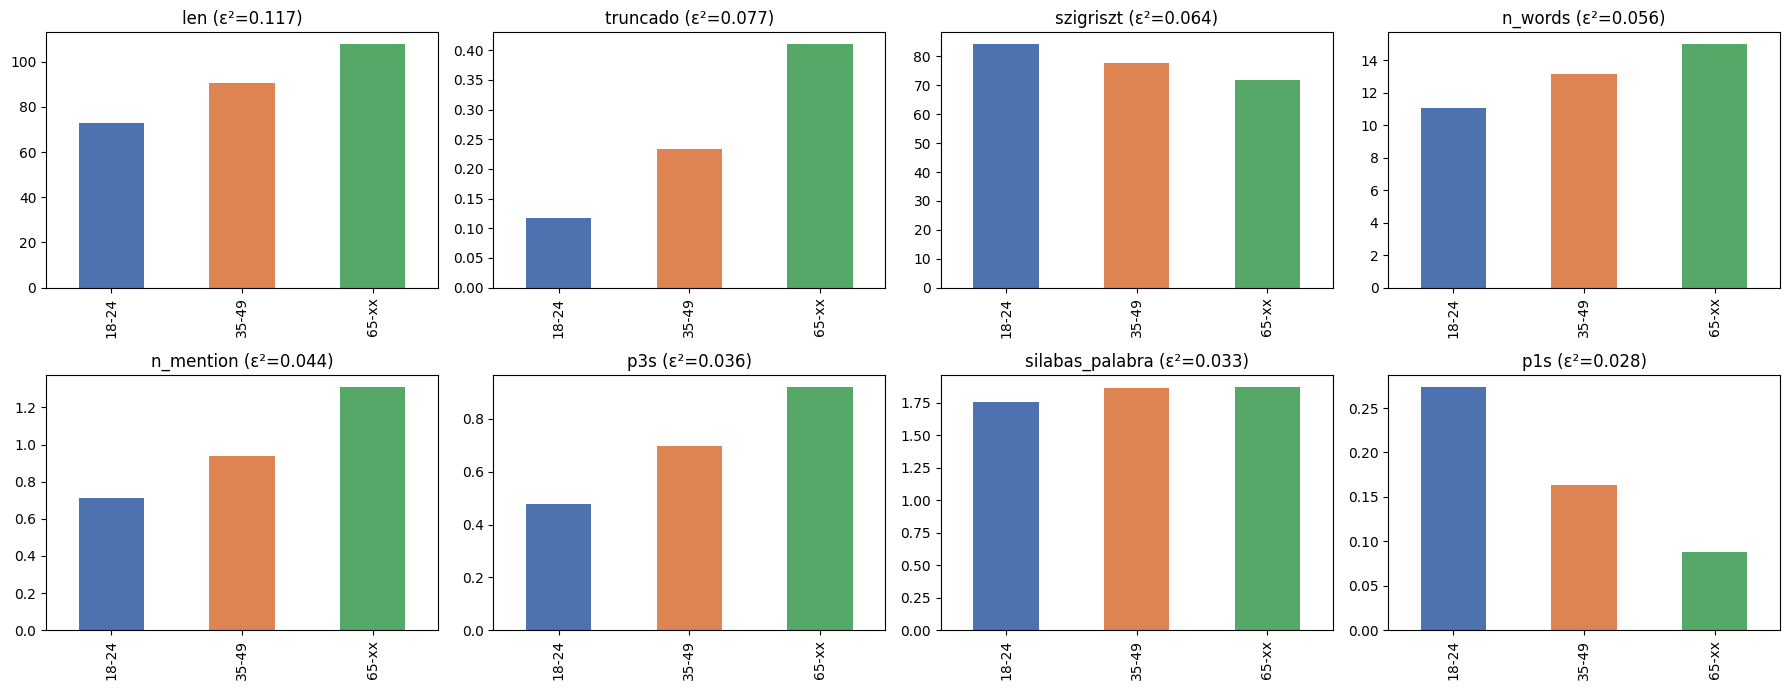

93

In [9]:
top = desc.index[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), top):
    D.groupby(train.y.values)[c].mean().reindex(GROUPS).plot.bar(ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(f'{c} (ε²={eps2[c]:.3f})'); ax.set_xlabel('')
plt.tight_layout(); plt.show()
del D; gc.collect()

**Qué esperar:** la longitud, el truncado, las menciones y la perspicuidad de Szigriszt-Pazos deberían encabezar la lista. Con la edad aumentan la longitud de los mensajes y de las palabras y disminuyen la primera persona singular, el tuteo, las risas y los alargamientos (Pennebaker & Stone, 2003; Nguyen et al., 2013).

## 5. Representación TF-IDF

Dos vectorizadores complementarios (sección 5 del informe):
- **Palabras 1-2:** el patrón `[@#]?\w+` conserva `@usuario` y `#hashtag` como tokens; `sublinear_tf=True` usa `1 + log(tf)`; `min_df=2` descarta términos únicos.
- **Caracteres 2-5 (`char_wb`):** n-gramas dentro de los límites de cada palabra; capturan abreviaturas, risas, alargamientos y errores. `lowercase=False` preserva las mayúsculas.

La clase `FeatureBuilder` ajusta los vectorizadores y escaladores **solo con los datos de entrenamiento** y luego transforma cualquier otro conjunto, para que no haya fuga de información. Las variables densas se escalan: los conteos con `log1p` + `MaxAbsScaler`; los índices de legibilidad (que pueden ser negativos) con `StandardScaler`. Los pesos `w_style` y `w_read` controlan cuánto pesan frente al TF-IDF.

In [10]:
class FeatureBuilder:
    def __init__(self, use_style=True, use_read=True, w_style=1.0, w_read=0.3,
                 word_max=200_000, char_max=200_000, reduce_flooding=False):
        self.use_style, self.use_read = use_style, use_read
        self.w_style, self.w_read = w_style, w_read
        self.reduce_flooding = reduce_flooding
        self.word = TfidfVectorizer(token_pattern=r'(?u)[@#]?\w+', ngram_range=(1, 2), min_df=2,
                                    sublinear_tf=True, max_features=word_max, dtype=np.float32)
        self.char = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=5, lowercase=False,
                                    sublinear_tf=True, max_features=char_max, dtype=np.float32)
        self.sc_style, self.sc_read = MaxAbsScaler(), StandardScaler()

    def _text(self, texts):
        t = pd.Series(texts).reset_index(drop=True)
        return t.str.replace(r'(\w)\1{2,}', r'\1\1', regex=True) if self.reduce_flooding else t

    def _blocks(self, texts, S, R, fit):
        t = self._text(texts)
        f = 'fit_transform' if fit else 'transform'
        blocks = [getattr(self.word, f)(t), getattr(self.char, f)(t)]
        if self.use_style:
            x = np.log1p(S.clip(lower=0).values).astype(np.float32)
            blocks.append(sparse.csr_matrix(getattr(self.sc_style, f)(x) * self.w_style))
        if self.use_read:
            x = R.values.astype(np.float32)
            blocks.append(sparse.csr_matrix(getattr(self.sc_read, f)(x) * self.w_read))
        return sparse.hstack(blocks).tocsr().astype(np.float32)

    def fit_transform(self, texts, S, R): return self._blocks(texts, S, R, fit=True)
    def transform(self, texts, S, R):     return self._blocks(texts, S, R, fit=False)

    def feature_names(self):
        names = list(self.word.get_feature_names_out()) + ['c:' + c for c in self.char.get_feature_names_out()]
        if self.use_style: names += list(S_train.columns)
        if self.use_read:  names += list(R_train.columns)
        return np.array(names)

## 6. Experimentos

### 6.1 Partición de validación
Holdout estratificado 80/20: rápido y suficiente con más de 100.000 tweets. El conjunto de test **no** se usa en ninguna decisión.

In [11]:
idx_tr, idx_va = train_test_split(np.arange(len(train)), test_size=0.2, stratify=train.y, random_state=SEED)
y_tr, y_va = train.y.values[idx_tr], train.y.values[idx_va]
T_tr, T_va = train.text.iloc[idx_tr], train.text.iloc[idx_va]
S_tr, S_va = S_train.iloc[idx_tr].reset_index(drop=True), S_train.iloc[idx_va].reset_index(drop=True)
R_tr, R_va = R_train.iloc[idx_tr].reset_index(drop=True), R_train.iloc[idx_va].reset_index(drop=True)
print(len(idx_tr), 'entrenamiento |', len(idx_va), 'validación')

135344 entrenamiento | 33837 validación


### 6.2 Ablación: ¿qué aporta cada bloque?
Se entrena el mismo clasificador (`LinearSVC`, C=0,3) cambiando solo la representación. Esto responde las preguntas del informe (Tabla 5): ¿aportan las variables de estilo?, ¿aporta la legibilidad?, ¿conviene reducir los alargamientos como sugiere el documento técnico?

In [12]:
results = []
def run_config(name, C=0.3, **kw):
    t0 = time.time(); fb = FeatureBuilder(**kw)
    Xa = fb.fit_transform(T_tr, S_tr, R_tr); Xb = fb.transform(T_va, S_va, R_va)
    pred = LinearSVC(C=C).fit(Xa, y_tr).predict(Xb)
    f1 = f1_score(y_va, pred, average='macro')
    results.append({'configuración': name, 'f1_macro': round(f1, 4), 'seg': round(time.time() - t0), 'kw': kw})
    print(f'{name:45s} F1 macro = {f1:.4f}')
    del Xa, Xb; gc.collect()

run_config('TF-IDF (palabras + caracteres)',    use_style=False, use_read=False)
run_config('TF-IDF + estilo',                   use_style=True,  use_read=False)
run_config('TF-IDF + estilo + legibilidad',     use_style=True,  use_read=True)
run_config('Ídem, alargamientos reducidos a 2', use_style=True,  use_read=True, reduce_flooding=True)
ablation = pd.DataFrame(results)            # en orden de complejidad creciente
TOL = 0.003                                 # diferencias menores se consideran ruido
chosen = ablation[ablation.f1_macro >= ablation.f1_macro.max() - TOL].iloc[0]
BEST_KW = chosen.kw                         # representación que se usa en el resto del notebook
print('Representación elegida:', chosen['configuración'], BEST_KW)
ablation.drop(columns='kw')

TF-IDF (palabras + caracteres)                F1 macro = 0.7045
TF-IDF + estilo                               F1 macro = 0.7072
TF-IDF + estilo + legibilidad                 F1 macro = 0.7078
Ídem, alargamientos reducidos a 2             F1 macro = 0.7081
Representación elegida: TF-IDF + estilo {'use_style': True, 'use_read': False}


,configuración,f1_macro,seg
0,TF-IDF (palabras + caracteres),0.7045,143
1,TF-IDF + estilo,0.7072,137
2,TF-IDF + estilo + legibilidad,0.7078,156233
3,"Ídem, alargamientos reducidos a 2",0.7081,17123


**Cómo leerlo:** se elige la configuración **más simple** cuyo F1 esté a menos de `TOL = 0,003` de la mejor, porque diferencias menores están dentro de la variación entre particiones (principio de parsimonia). La elegida se guarda en `BEST_KW` y se usa automáticamente en las secciones siguientes y en el modelo final. Si una fila no mejora a la anterior en al menos ~0,002, su aporte es marginal. En pruebas previas, las variables de estilo sumaron +0,004, en línea con Moreno-Sandoval et al. (2021), que encontraron que ayudan poco en rendimiento pero mucho en interpretación. Reducir los alargamientos debería empeorar o no cambiar el resultado, porque esa marca disminuye con la edad.

### 6.3 Selección de clasificador e hiperparámetros
Con la representación elegida (`BEST_KW`) se comparan tres clasificadores lineales (sección 6 del informe):
- **LinearSVC:** SVM lineal (LIBLINEAR), referencia en texto disperso (Joachims, 1998). Se ajusta la regularización `C`.
- **SGDClassifier con `log_loss`:** regresión logística entrenada por descenso de gradiente estocástico; entrega probabilidades. Moreno-Sandoval et al. (2018) lo reportan como el mejor estimador. Se ajusta `alpha`.
- **ComplementNB:** Naive Bayes adaptado a texto (Rennie et al., 2003); requiere valores no negativos, por eso usa solo el TF-IDF.

In [13]:
fb = FeatureBuilder(**BEST_KW)
X_tr = fb.fit_transform(T_tr, S_tr, R_tr); X_va = fb.transform(T_va, S_va, R_va)
n_text = len(fb.word.vocabulary_) + len(fb.char.vocabulary_)   # columnas TF-IDF (no negativas)
print('Matriz de entrenamiento:', X_tr.shape)

models, scores = {}, []
def evaluate(name, model, Xa, Xb):
    t0 = time.time(); model.fit(Xa, y_tr); pred = model.predict(Xb)
    f1 = f1_score(y_va, pred, average='macro'); models[name] = model
    scores.append({'modelo': name, 'f1_macro': round(f1, 4), 'seg': round(time.time() - t0)})
    print(f'{name:32s} F1 macro = {f1:.4f}')

for C in [0.1, 0.3, 0.6]:
    evaluate(f'LinearSVC C={C}', LinearSVC(C=C), X_tr, X_va)
for a in [2e-6, 5e-6, 2e-5]:
    evaluate(f'SGD-log alpha={a}', SGDClassifier(loss='log_loss', alpha=a, max_iter=30, tol=1e-4, random_state=SEED), X_tr, X_va)
evaluate('ComplementNB alpha=0.3', ComplementNB(alpha=0.3), X_tr[:, :n_text], X_va[:, :n_text])
model_table = pd.DataFrame(scores).sort_values('f1_macro', ascending=False)
model_table

Matriz de entrenamiento: (135344, 400029)
LinearSVC C=0.1                  F1 macro = 0.7034
LinearSVC C=0.3                  F1 macro = 0.7072
LinearSVC C=0.6                  F1 macro = 0.7024
SGD-log alpha=2e-06              F1 macro = 0.7000
SGD-log alpha=5e-06              F1 macro = 0.6992
SGD-log alpha=2e-05              F1 macro = 0.6845
ComplementNB alpha=0.3           F1 macro = 0.6779


,modelo,f1_macro,seg
1,LinearSVC C=0.3,0.7072,54
0,LinearSVC C=0.1,0.7034,28
2,LinearSVC C=0.6,0.7024,83
3,SGD-log alpha=2e-06,0.7000,26
4,SGD-log alpha=5e-06,0.6992,26
5,SGD-log alpha=2e-05,0.6845,26
6,ComplementNB alpha=0.3,0.6779,1


### 6.4 Ensamble por votación suave
Se promedian las probabilidades de dos modelos que se equivocan de forma distinta: el mejor SVM lineal (calibrado con `CalibratedClassifierCV` para obtener probabilidades) y el mejor SGD logístico. Es una forma sencilla de ganar estabilidad (sección 6 del informe). Se prueban varios pesos del SVM.

In [14]:
best_svc = model_table[model_table.modelo.str.startswith('LinearSVC')].iloc[0].modelo
best_sgd = model_table[model_table.modelo.str.startswith('SGD')].iloc[0].modelo
C_best, alpha_best = models[best_svc].C, models[best_sgd].alpha

svc_cal = CalibratedClassifierCV(LinearSVC(C=C_best), cv=3, method='sigmoid').fit(X_tr, y_tr)
P_svc = svc_cal.predict_proba(X_va)
P_sgd = models[best_sgd].predict_proba(X_va)
classes = svc_cal.classes_
assert list(classes) == list(models[best_sgd].classes_)

ens = []
for w in [0.5, 0.6, 0.7, 0.8, 1.0]:
    pred = classes[(w * P_svc + (1 - w) * P_sgd).argmax(1)]
    ens.append({'peso_svm': w, 'f1_macro': round(f1_score(y_va, pred, average='macro'), 4)})
ens = pd.DataFrame(ens); W_BEST = ens.sort_values('f1_macro', ascending=False).iloc[0].peso_svm
print('Mejor peso del SVM en el ensamble:', W_BEST)
ens

Mejor peso del SVM en el ensamble: 1.0


,peso_svm,f1_macro
0,0.5,0.7041
1,0.6,0.7049
2,0.7,0.7058
3,0.8,0.7070
4,1.0,0.7074


### 6.5 Validación cruzada (opcional)
Con `RUN_CV=True` se estima la variabilidad del modelo elegido con 5 particiones estratificadas. Los vectorizadores se reajustan en cada partición para evitar fuga de información.

In [15]:
if RUN_CV:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = []
    for k, (a, b) in enumerate(skf.split(train.text, train.y)):
        fbk = FeatureBuilder(**BEST_KW)
        Xa = fbk.fit_transform(train.text.iloc[a], S_train.iloc[a], R_train.iloc[a])
        Xb = fbk.transform(train.text.iloc[b], S_train.iloc[b], R_train.iloc[b])
        pred = LinearSVC(C=C_best).fit(Xa, train.y.values[a]).predict(Xb)
        cv_scores.append(f1_score(train.y.values[b], pred, average='macro'))
        print(f'Partición {k+1}: {cv_scores[-1]:.4f}')
        del Xa, Xb; gc.collect()
    print(f'F1 macro CV: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

## 7. Evaluación e interpretación

### 7.1 Métricas por clase y matriz de confusión
En problemas de edad los errores suelen concentrarse entre grupos contiguos (Nguyen et al., 2013); se espera que `35-49` sea la clase más difícil.

              precision    recall  f1-score   support

       18-24      0.731     0.756     0.743     11483
       35-49      0.641     0.596     0.617     11310
       65-xx      0.748     0.776     0.762     11044

    accuracy                          0.709     33837
   macro avg      0.707     0.709     0.707     33837
weighted avg      0.706     0.709     0.707     33837



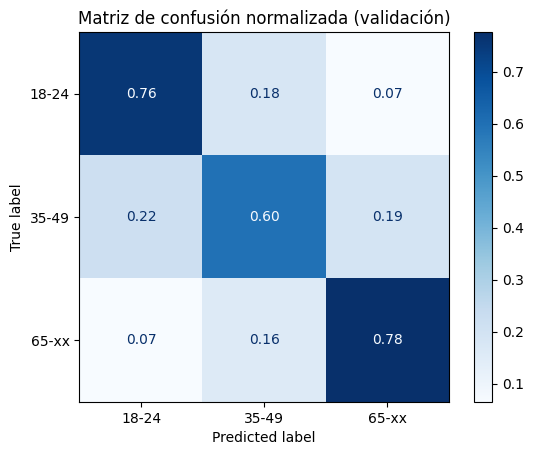

In [16]:
pred_ens = classes[(W_BEST * P_svc + (1 - W_BEST) * P_sgd).argmax(1)]
print(classification_report(y_va, pred_ens, digits=3))
ConfusionMatrixDisplay.from_predictions(y_va, pred_ens, labels=GROUPS, normalize='true', values_format='.2f', cmap='Blues')
plt.title('Matriz de confusión normalizada (validación)'); plt.show()

In [17]:
# Ejemplos de errores para análisis cualitativo
va = pd.DataFrame({'text': T_va.values, 'real': y_va, 'pred': pred_ens})
va[va.real != va.pred].sample(12, random_state=SEED)

,text,real,pred
28636,Hagamos esto realidad,35-49,18-24
33811,Parece es un version 50 sombras. https://t.co/M17mYzJYRN,18-24,65-xx
6188,"He anadido un video a una lista de reproduccion de @YouTube (https://t.co/ir1R7dKTFK - Best Version of Jesu, Joy Of ...",18-24,35-49
24766,"@chipakero es d los grandes futbolistas extranjeros q han venido a colombia. esto le hace bn a FPC, pero un tecnico ...",35-49,65-xx
12753,"Mejor ya llevame contigo Valentin elizalde, mi gallo de oro",35-49,18-24
1455,Hola china como estas ?,35-49,18-24
30396,https://t.co/Dj4CsQ8ZqU,18-24,65-xx
9388,RT @PLinero: Dios nos bendice en este momento. El esta a nuestro lado; su fuerza nos empuja para alcanzar la victori...,35-49,65-xx
24735,RT @Juan_Luiis03: Ya se va Ya se va @ElectricaribeSA ya se va,35-49,18-24
7520,RT @NacionalsPasion: Breves de NEP... De 4 a 6 semanas sera la incapacidad de Camilo Vargas... https://t.co/2w26dDHe3V,35-49,65-xx


### 7.2 ¿Qué aprendió el modelo? Términos más influyentes
Los coeficientes del SVM lineal indican qué n-gramas empujan hacia cada grupo. Sirven para verificar que el modelo aprende señales plausibles (pronombres, risas y fandom en jóvenes; política y palabras largas en mayores) y no artefactos.

In [18]:
svm = models[best_svc]
names = fb.feature_names()
dense_cols = set(S_train.columns) | set(R_train.columns)
top_terms = {}
for i, k in enumerate(svm.classes_):
    order = np.argsort(-svm.coef_[i])
    top_terms[k] = [names[j] for j in order if not names[j].startswith('c:') and names[j] not in dense_cols][:20]
pd.DataFrame(top_terms)

,18-24,35-49,65-xx
0,llap,#actualidad https,#frtrends
1,@justinbieber,#gh2015,meza
2,b https,foto de,lisandro
3,@rubiu5,rt @noticiascaracol,lizandro
4,@karolsevilla,rt @bogota,@_guerrapedro
5,saludos desde,@youtube buenos,#macri
6,#extreno,rt @prensacom,@adrianrubalcava
7,de fotos,rt @alvarouribevel,@rochy62
8,nose,@radionica,bada
9,rt @libertadchile1,#actualidad,@franklinramost


### 7.3 Efecto de las variables de estilo y legibilidad
Para interpretar las variables densas se entrena una regresión logística multinomial **solo con ellas**, estandarizadas. Cada coeficiente es el cambio en el log-odds de pertenecer a ese grupo por un aumento de una desviación estándar en la variable, con las demás constantes. Es el equivalente, en scikit-learn, del modelo logit multinomial que usan Moreno-Sandoval et al. (2021) para explicar las variables.

In [19]:
def dense(S, R):
    return np.column_stack([np.log1p(S.clip(lower=0).values), R.values])
sc_dense = StandardScaler().fit(dense(S_tr, R_tr))
lr_dense = LogisticRegression(max_iter=2000).fit(sc_dense.transform(dense(S_tr, R_tr)), y_tr)
f1_dense = f1_score(y_va, lr_dense.predict(sc_dense.transform(dense(S_va, R_va))), average='macro')
print(f'F1 macro solo con variables densas: {f1_dense:.4f}')
coef = pd.DataFrame(lr_dense.coef_.T, index=list(S_tr.columns) + list(R_tr.columns), columns=lr_dense.classes_)
coef['rango'] = coef.max(axis=1) - coef.min(axis=1)
coef.sort_values('rango', ascending=False).round(3).head(15)

F1 macro solo con variables densas: 0.5253


,18-24,35-49,65-xx,rango
len,-0.387,-0.127,0.514,0.901
respuesta,-0.209,0.060,0.148,0.357
risa,0.146,0.044,-0.190,0.336
p1s,0.174,-0.013,-0.161,0.335
n_url,-0.209,0.089,0.120,0.329
truncado,-0.165,0.021,0.144,0.308
solo_url,-0.143,-0.019,0.161,0.304
n_mention,-0.169,0.038,0.131,0.300
rt,0.198,-0.100,-0.098,0.299
p3s,-0.139,0.004,0.135,0.274


**Lectura:** un coeficiente positivo en `18-24` para `p1s` significa que usar más la primera persona singular aumenta la probabilidad de pertenecer al grupo joven. Las variables densas solas logran un F1 muy inferior al TF-IDF, pero permiten explicar el comportamiento de cada grupo en el informe.

## 8. Modelo final y submission

El modelo final repite la mejor configuración entrenando con **todo** el train. Luego se aplican dos reglas:
1. **Duplicados exactos:** si un tweet de test es idéntico a uno de train cuya etiqueta es unánime, se usa esa etiqueta (es información del train, no del test).
2. **Tweets vacíos o `#¿NOMBRE?`:** se les asigna la clase más frecuente de esos casos en el train.

Por último, se copia el encabezado exacto de `age_sample_submission.csv` para evitar errores de formato.

In [20]:
del X_tr, X_va, models, svc_cal, P_svc, P_sgd; gc.collect()
t0 = time.time()
fb_final = FeatureBuilder(**BEST_KW)
X_all  = fb_final.fit_transform(train.text, S_train, R_train)
X_test = fb_final.transform(test.text, S_test, R_test)

svc_final = CalibratedClassifierCV(LinearSVC(C=C_best), cv=3, method='sigmoid').fit(X_all, train.y.values)
P = W_BEST * svc_final.predict_proba(X_test)
if W_BEST < 1:
    sgd_final = SGDClassifier(loss='log_loss', alpha=alpha_best, max_iter=30, tol=1e-4, random_state=SEED).fit(X_all, train.y.values)
    P += (1 - W_BEST) * sgd_final.predict_proba(X_test)
test['age_range'] = svc_final.classes_[P.argmax(1)]
print(f'Modelo final entrenado y aplicado ({time.time()-t0:.0f}s)')

# Regla 1: duplicados exactos con etiqueta unánime en train
lab = train.groupby('text').y.agg(['nunique', 'first'])
lookup = lab.loc[lab['nunique'] == 1, 'first']
hit = test.text.isin(lookup.index) & (test.text != '')
test.loc[hit, 'age_range'] = test.loc[hit, 'text'].map(lookup)
print('Predicciones reemplazadas por duplicado exacto:', int(hit.sum()))

# Regla 2: vacíos y artefacto de Excel
raw = train_raw.assign(y=train_raw.age_range.map(MAP_AGRUPAR) if MODE == 'agrupar' else train_raw.age_range)
raw = raw[raw.y.isin(GROUPS)]
junk_train = is_junk(prep(raw.text)).values
default = raw.y[junk_train].mode().iloc[0] if junk_train.any() else train.y.mode().iloc[0]
junk_test = is_junk(test.text).values
test.loc[junk_test, 'age_range'] = default
print(f'Vacíos o #¿NOMBRE? en test: {int(junk_test.sum())} → {default}')

Modelo final entrenado y aplicado (251s)
Predicciones reemplazadas por duplicado exacto: 1117
Vacíos o #¿NOMBRE? en test: 99 → 18-24


In [21]:
# Encabezado exacto del archivo de muestra (si está disponible)
if os.path.exists(SAMPLE_PATH):
    sample_cols = pd.read_csv(SAMPLE_PATH, nrows=0, sep=None, engine='python', encoding='utf-8-sig').columns.tolist()
else:
    sample_cols = ['ID', 'age_range']
sub = pd.DataFrame({sample_cols[0]: test['id'].astype(int), sample_cols[1]: test['age_range']})

assert len(sub) == len(test_raw), 'Faltan filas en la submission'
assert sub[sample_cols[1]].isin(GROUPS).all(), 'Hay etiquetas fuera de los tres grupos'
sub.to_csv(OUT_PATH, index=False)
print('Archivo guardado:', OUT_PATH, sub.shape)
print(sub[sample_cols[1]].value_counts(normalize=True).round(3))
sub.head()

Archivo guardado: age_submission.csv (112892, 2)
age_range
18-24    0.347
65-xx    0.340
35-49    0.313
Name: proportion, dtype: float64


,ID,age_range
0,1,65-xx
1,2,18-24
2,3,18-24
3,4,35-49
4,5,65-xx


## 9. Conclusiones y próximos pasos
- Una representación dispersa de palabras y caracteres con un clasificador lineal regularizado es una base sólida sin modelos preentrenados, como anticipa la literatura de PAN.
- Las decisiones de preprocesamiento basadas en el descriptivo (conservar @usuarios y alargamientos) pesan más en el resultado que el cambio de clasificador.
- Las variables de estilo y legibilidad aportan poco al F1, pero hacen el modelo explicable y confirman los patrones sociolingüísticos esperados.
- El grupo intermedio concentra los errores; mejoras posibles: aprovechar el orden de las clases (Frank & Hall, 2001), ajustar umbrales por clase sobre las probabilidades del ensamble o probar LDSE (Rangel et al., 2016).

Las referencias completas en formato APA están en el informe de estado del arte del equipo.